# LOS<8 Prediction — Random Forest Model (Lab-Only Dataset)

Simple end-to-end pipeline: load data, train a Random Forest classifier, and evaluate it. No exploratory plots — straight to modeling and results.

This version is adapted for a dataset containing **only lab-value features** (no demographic/admission fields):
`ALT, Amylase, Bilirubin, Calcium, Creatinine, Creatine Kinase, Hematocrit, Lactate, Lipase, MCH, MCHC, MCV, PT, WBC`

**Target:** `LOS<8` — 1 = length of stay < 8 days, 0 = length of stay ≥ 8 days.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

%matplotlib inline


## 1. Load data


In [2]:
# Update this path to point to your dataset (xlsx or csv)
data_path = '../sample_datasets/MIMIC3LAB.xlsx'

if data_path.lower().endswith('.csv'):
    df = pd.read_csv(data_path)
else:
    df = pd.read_excel(data_path)

print('Shape:', df.shape)


Shape: (943, 15)


## 2. Prepare data for modeling


In [3]:
# No categorical columns in this dataset - use lab features directly
X = df.drop(columns=['LOS<8'])
y = df['LOS<8']

print('Feature matrix shape:', X.shape)


Feature matrix shape: (943, 14)


## 3. Train/test split


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (754, 14)  Test shape: (189, 14)


## 4. Train the Random Forest model


In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

## 5. Evaluate the model


In [6]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('\nClassification report:\n', classification_report(y_test, y_pred))


Accuracy: 0.7566137566137566
ROC-AUC: 0.8385625000000001

Classification report:
               precision    recall  f1-score   support

           0       0.76      0.92      0.83       125
           1       0.74      0.44      0.55        64

    accuracy                           0.76       189
   macro avg       0.75      0.68      0.69       189
weighted avg       0.75      0.76      0.74       189



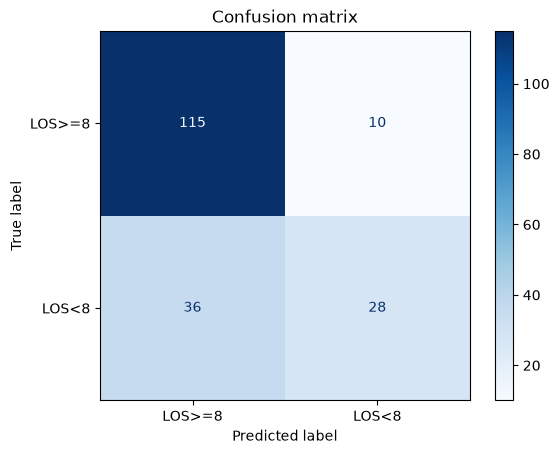

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LOS>=8', 'LOS<8'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()


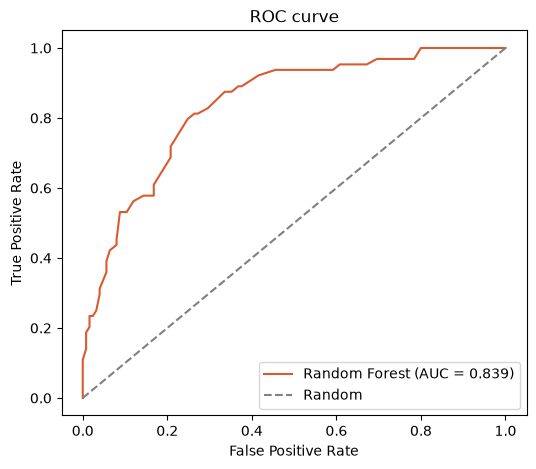

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})', color='#D85A30')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.show()


## 6. Feature importance


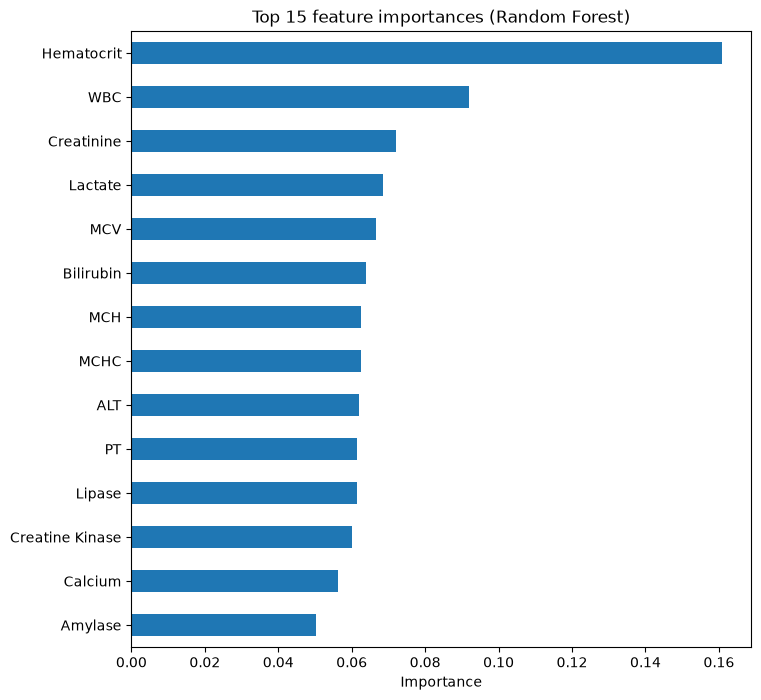

In [9]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances (Random Forest)')
plt.xlabel('Importance')
plt.show()


## 7. Results summary (for your report)


In [10]:
print('=== Model Results Summary ===')
print('Model: Random Forest Classifier')
print(f'Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

report_dict = classification_report(y_test, y_pred, output_dict=True)
print(f"Precision (LOS<8=1): {report_dict['1']['precision']:.3f}")
print(f"Recall (LOS<8=1): {report_dict['1']['recall']:.3f}")
print(f"F1-score (LOS<8=1): {report_dict['1']['f1-score']:.3f}")


=== Model Results Summary ===
Model: Random Forest Classifier
Train samples: 754, Test samples: 189
Accuracy: 0.757
ROC-AUC: 0.839
Precision (LOS<8=1): 0.737
Recall (LOS<8=1): 0.438
F1-score (LOS<8=1): 0.549
